# Verification: QUICGraphicalLassoCV vs GraphicalLassoCV

Validates that `QUICGraphicalLassoCV` (`quic_cv.py`) recovers the true precision matrix at the same rate as sklearn's `GraphicalLassoCV` as sample size grows.

**Setup:** A ground-truth sparse precision matrix `iC_true` is generated from a cluster graph (`p=256`). For each sample size `n ∈ {10, 100, 1000, 10000}`, both estimators are fit on `Y ~ N(0, C_true)` and the Frobenius error `‖iC_hat − iC_true‖_F` is recorded.

**Pass criterion:** Both error curves should decrease at the same rate on the log-log plot, confirming that the QUIC-based CV selects alpha comparably to the coordinate-descent glasso.

/opt/homebrew/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


QUICGraphicalLassoCV - Done 5.396176815032959 sec


/opt/homebrew/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/opt/homebrew/lib/python3.12/site-packages/sklearn/covariance/_graph_lasso.py:199: ConvergenceWarning: graphical_lasso: did not converge after 100 iteration: dual gap: 2.895e-02
  warnings.warn(


GraphicalLassoCV - Done 6.1454339027404785 sec


/opt/homebrew/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


QUICGraphicalLassoCV - Done 1.179581880569458 sec


/opt/homebrew/lib/python3.12/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


GraphicalLassoCV - Done 3.5160131454467773 sec
QUICGraphicalLassoCV - Done 2.302182197570801 sec
GraphicalLassoCV - Done 4.001763820648193 sec
QUICGraphicalLassoCV - Done 2.989748001098633 sec
GraphicalLassoCV - Done 3.8062939643859863 sec


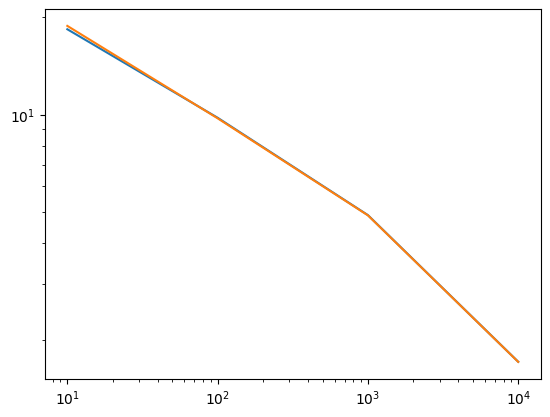

In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"       # If using Intel MKL
os.environ["NUMEXPR_NUM_THREADS"] = "1"   # If using NumExpr
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  # macOS Accelerate framework

import pickle
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import nibabel as nib
from _util import *

from sklearn.covariance import GraphicalLassoCV
from _QUICGraphicalLassoCV import QUICGraphicalLassoCV    

iC_true, C_true = make_cov(p=256,data_type='cluster')

err_1 = []
err_2 = []

n_set = [10,100,1000,10000]

for n in n_set:

    Y = make_samples(cov=C_true,n=n)

    t = time.time()                                                                                                     
    model = QUICGraphicalLassoCV(tol=1e-4,max_iter=100,n_jobs=-1,)
    model.fit(Y.T)
    iC = model.precision_  
    C  = model.covariance_
    alpha = model.alpha_
    err_1.append(np.linalg.norm(iC_true-iC))
    t = time.time() - t
    print(f'QUICGraphicalLassoCV - Done {t} sec')

    t = time.time()   
    model = GraphicalLassoCV(tol=1e-4, max_iter=100,n_jobs=-1)  
    model.fit(Y.T)
    iC = model.precision_
    C  = model.covariance_
    alpha = model.alpha_
    err_2.append(np.linalg.norm(iC_true-iC))
    t = time.time() - t
    print(f'GraphicalLassoCV - Done {t} sec')

plt.loglog(n_set,err_1)
plt.loglog(n_set,err_2)